# 05 - Extraction Embeddings LLM (DistilBERT)

**SAE-112** — Epic 3 : Text Representation

## Objectif
Extraire des embeddings de documents à partir de **DistilBERT** pré-entraîné (HuggingFace).
Ces embeddings seront utilisés par les notebooks ML classique (SAE-117) et Deep Learning.

**Grille :** LLM (1pt)

### Stratégie d'extraction
- **Mean Pooling** : moyenne des hidden states de la dernière couche (excluant les tokens spéciaux)
- Dimension de sortie : **768** par document

## 1. Setup & Imports

In [ ]:
import sys
import os
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertModel
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

from src.constants import RANDOM_STATE, stars_to_polarity
from src.dl_utils import get_device

device = get_device()
print(f'Device : {device}')
print(f'PyTorch : {torch.__version__}')
print('Imports OK')

## 2. Chargement des données prétraitées

In [ ]:
from sklearn.model_selection import train_test_split

# Chargement du dataset nettoyé
data_path = '../../data/cleaned/reviews_clean.parquet'
reviews_full = pd.read_parquet(data_path, columns=['text', 'stars'])
print(f'Dataset complet : {len(reviews_full):,} reviews')

# Créer la polarité (négatif=0, neutre=1, positif=2)
reviews_full['polarity'] = reviews_full['stars'].apply(stars_to_polarity)

# Échantillonnage stratifié — 50 000 reviews (DistilBERT sur 1M serait trop long)
SAMPLE_SIZE = 50_000

reviews, _ = train_test_split(
    reviews_full,
    train_size=SAMPLE_SIZE,
    stratify=reviews_full['polarity'],
    random_state=RANDOM_STATE
)
reviews = reviews.reset_index(drop=True)

print(f'Échantillon stratifié : {len(reviews):,} reviews')
print(f'\nDistribution de polarité :')
print(reviews['polarity'].value_counts().sort_index().to_frame('count'))
print('  0=négatif (1-2★), 1=neutre (3★), 2=positif (4-5★)')
print(f'\nExemple de texte : {reviews["text"].iloc[0][:150]}...')
reviews.head()

In [3]:
# Vérification du texte source pour DistilBERT
text_column = 'text'

print(f'Colonne texte : {text_column}')
print(f'Textes vides : {(reviews[text_column].isna() | (reviews[text_column] == "")).sum()}')
print(f'Longueur moyenne : {reviews[text_column].str.len().mean():.0f} caractères')
print(f'Longueur médiane : {reviews[text_column].str.len().median():.0f} caractères')

Colonne texte : text
Textes vides : 0
Longueur moyenne : 569 caractères
Longueur médiane : 405 caractères


## 3. Chargement de DistilBERT

In [4]:
model_name = 'distilbert-base-uncased'

print(f'Chargement du tokenizer {model_name}...')
tokenizer = DistilBertTokenizer.from_pretrained(model_name)

print(f'Chargement du modèle {model_name}...')
model = DistilBertModel.from_pretrained(model_name)
model = model.to(device)
model.eval()

print(f'\nModèle chargé !')
print(f'  Paramètres : {sum(p.numel() for p in model.parameters()):,}')
print(f'  Hidden size : {model.config.hidden_size}')
print(f'  Max length  : {tokenizer.model_max_length}')

Chargement du tokenizer distilbert-base-uncased...


Chargement du modèle distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Modèle chargé !
  Paramètres : 66,362,880
  Hidden size : 768
  Max length  : 512


## 4. Extraction des embeddings

On utilise le **mean pooling** sur les hidden states de la dernière couche,
en masquant les tokens de padding pour ne pas fausser la moyenne.

In [5]:
def mean_pooling(model_output, attention_mask):
    """
    Mean pooling sur les hidden states, en tenant compte du masque d'attention.
    """
    token_embeddings = model_output.last_hidden_state  # (batch, seq_len, hidden)
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask


def extract_embeddings(texts, tokenizer, model, batch_size=32, max_length=512):
    """
    Extrait les embeddings DistilBERT pour une liste de textes.
    
    Args:
        texts: Liste de textes
        tokenizer: DistilBERT tokenizer
        model: DistilBERT model
        batch_size: Taille des batchs
        max_length: Longueur max de tokenisation (tronqué)
    
    Returns:
        embeddings: np.array de shape (n_texts, 768)
    """
    all_embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc='Extraction embeddings'):
        batch_texts = texts[i:i + batch_size]
        
        # Tokenisation
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(device)
        
        # Extraction (sans gradient pour économiser la mémoire)
        with torch.no_grad():
            outputs = model(**encoded)
        
        # Mean pooling
        embeddings = mean_pooling(outputs, encoded['attention_mask'])
        all_embeddings.append(embeddings.cpu().numpy())
    
    return np.concatenate(all_embeddings, axis=0)

print('Fonctions d\'extraction définies')

Fonctions d'extraction définies


In [6]:
# Extraire les embeddings
texts = reviews[text_column].fillna('').tolist()

print(f'Extraction des embeddings pour {len(texts):,} documents...')
print(f'Batch size : 64 | Max length : 512 | Device : {device}')

embeddings = extract_embeddings(texts, tokenizer, model, batch_size=64, max_length=512)

print(f'\nEmbeddings extraits !')
print(f'  Shape : {embeddings.shape}')
print(f'  Dtype : {embeddings.dtype}')
print(f'  Mémoire : {embeddings.nbytes / 1024 / 1024:.1f} MB')

Extraction des embeddings pour 50,000 documents...
Batch size : 64 | Max length : 512 | Device : mps


Extraction embeddings:   0%|          | 0/782 [00:00<?, ?it/s]

Extraction embeddings:   0%|          | 1/782 [00:02<31:03,  2.39s/it]

Extraction embeddings:   0%|          | 2/782 [00:04<29:14,  2.25s/it]

Extraction embeddings:   0%|          | 3/782 [00:06<28:42,  2.21s/it]

...

Extraction embeddings: 100%|█████████▉| 780/782 [45:01<00:07,  3.69s/it]

Extraction embeddings: 100%|█████████▉| 781/782 [45:05<00:03,  3.67s/it]

Extraction embeddings: 100%|██████████| 782/782 [45:17<00:00,  6.12s/it]

Extraction embeddings: 100%|██████████| 782/782 [45:17<00:00,  3.47s/it]


Embeddings extraits !
  Shape : (50000, 768)
  Dtype : float32
  Mémoire : 146.5 MB


## 5. Vérification rapide

In [7]:
# Statistiques basiques
print('Statistiques des embeddings :')
print(f'  Moyenne   : {embeddings.mean():.6f}')
print(f'  Std       : {embeddings.std():.6f}')
print(f'  Min       : {embeddings.min():.6f}')
print(f'  Max       : {embeddings.max():.6f}')

# Vérifier les vecteurs nuls
zero_vectors = np.sum(np.all(embeddings == 0, axis=1))
print(f'  Vecteurs nuls : {zero_vectors} / {len(embeddings)}')

# Aperçu du premier embedding
print(f'\nPremier embedding (10 premières dims) :')
print(f'  {embeddings[0][:10]}')

Statistiques des embeddings :


  Moyenne   : -0.010737
  Std       : 0.279481
  Min       : -4.667798
  Max       : 1.753844
  Vecteurs nuls : 0 / 50000

Premier embedding (10 premières dims) :
  [-0.10693935  0.02811921  0.18162026  0.16155262  0.31085718  0.03312443
  0.0455471   0.37171355 -0.03034535 -0.1845004 ]


## 6. Visualisation t-SNE

In [ ]:
# Sous-échantillon pour t-SNE (trop lent sur 50K)
VIS_SAMPLE = 5000
np.random.seed(RANDOM_STATE)
vis_idx = np.random.choice(len(embeddings), VIS_SAMPLE, replace=False)
embeddings_vis = embeddings[vis_idx]
polarity_vis = reviews['polarity'].values[vis_idx]

# Réduction PCA avant t-SNE (accélère le calcul)
print(f'Réduction PCA (768 → 50) sur {VIS_SAMPLE:,} points...')
pca = PCA(n_components=50, random_state=RANDOM_STATE)
embeddings_pca = pca.fit_transform(embeddings_vis)
print(f'Variance expliquée : {pca.explained_variance_ratio_.sum():.2%}')

# t-SNE
print('Calcul t-SNE (50 → 2)...')
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings_pca)

print(f't-SNE terminé : shape = {embeddings_2d.shape}')

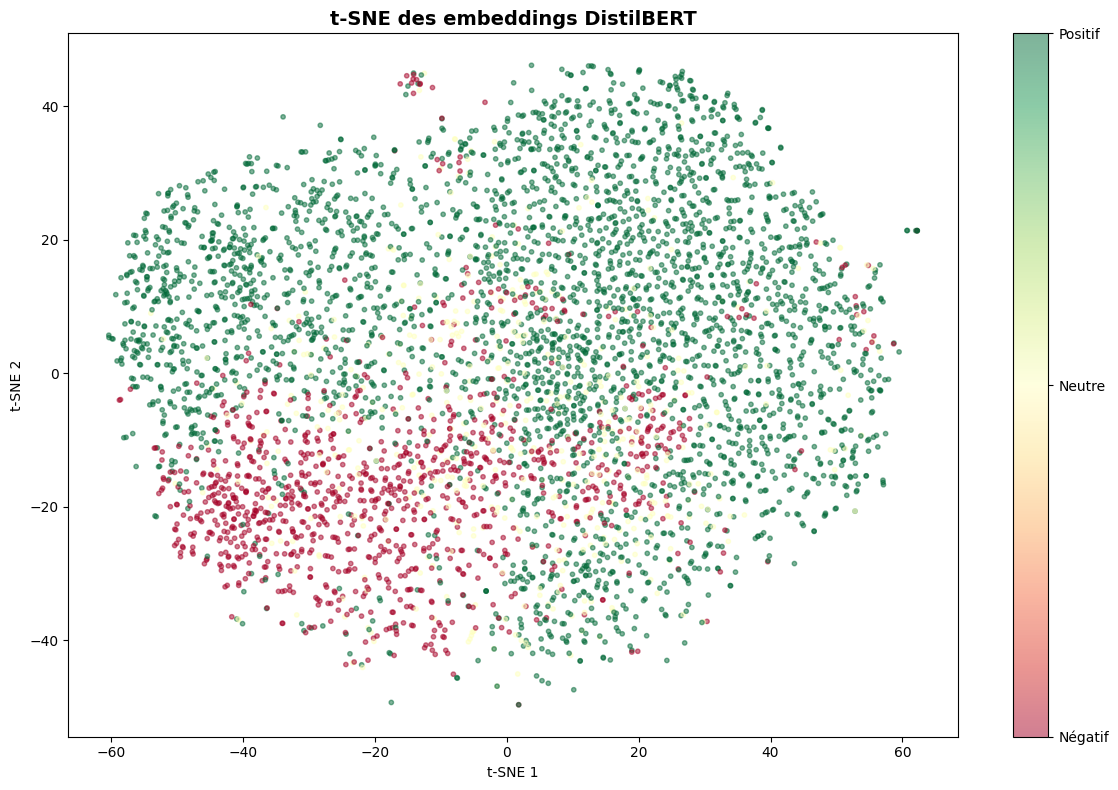

Figure sauvegardée : outputs/figures/tsne_distilbert.png


In [9]:
# Visualisation
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1],
    c=polarity_vis, cmap='RdYlGn', alpha=0.5, s=10
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['Négatif', 'Neutre', 'Positif'])

ax.set_title('t-SNE des embeddings DistilBERT', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

plt.tight_layout()
os.makedirs('../../outputs/figures', exist_ok=True)
plt.savefig('../../outputs/figures/tsne_distilbert.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : outputs/figures/tsne_distilbert.png')

## 7. Sauvegarde des embeddings

In [10]:
# Sauvegarder dans outputs/ pour les notebooks ML
output_dir = '../../outputs'
os.makedirs(output_dir, exist_ok=True)

# Embeddings
embeddings_path = os.path.join(output_dir, 'distilbert_embeddings.npy')
np.save(embeddings_path, embeddings)
print(f'Embeddings sauvegardés : {embeddings_path}')
print(f'  Shape : {embeddings.shape}')

# Labels polarité (3 classes : 0=négatif, 1=neutre, 2=positif)
labels_polarity = reviews['polarity'].values
np.save(os.path.join(output_dir, 'distilbert_labels_polarity.npy'), labels_polarity)
print(f'Labels polarité sauvegardés : {len(labels_polarity):,}')
print(f'  Distribution : {dict(zip(*np.unique(labels_polarity, return_counts=True)))}')

# Labels score (1-5 étoiles)
labels_score = reviews['stars'].values
np.save(os.path.join(output_dir, 'distilbert_labels_score.npy'), labels_score)
print(f'Labels score sauvegardés    : {len(labels_score):,}')
print(f'  Distribution : {dict(zip(*np.unique(labels_score, return_counts=True)))}')

print(f'\n✅ Fichiers prêts pour SAE-117 (ML sur embeddings LLM)')

Embeddings sauvegardés : ../../outputs/distilbert_embeddings.npy
  Shape : (50000, 768)
Labels polarité sauvegardés : 50,000
  Distribution : {np.int64(0): np.int64(11534), np.int64(1): np.int64(4936), np.int64(2): np.int64(33530)}
Labels score sauvegardés    : 50,000
  Distribution : {np.int64(1): np.int64(7667), np.int64(2): np.int64(3867), np.int64(3): np.int64(4936), np.int64(4): np.int64(10307), np.int64(5): np.int64(23223)}

✅ Fichiers prêts pour SAE-117 (ML sur embeddings LLM)


In [11]:
print('\n✅ Notebook SAE-112 terminé avec succès !')
print(f'   Embeddings DistilBERT extraits pour {len(embeddings):,} documents')
print(f'   Dimension : {embeddings.shape[1]}')
print(f'   Fichiers :')
print(f'     - outputs/distilbert_embeddings.npy')
print(f'     - outputs/distilbert_labels_polarity.npy')
print(f'     - outputs/distilbert_labels_score.npy')


✅ Notebook SAE-112 terminé avec succès !
   Embeddings DistilBERT extraits pour 50,000 documents
   Dimension : 768
   Fichiers :
     - outputs/distilbert_embeddings.npy
     - outputs/distilbert_labels_polarity.npy
     - outputs/distilbert_labels_score.npy
